# **Recognition Benchmark**
**EasyOCR vs TrOCR**

**Input:** `data/processed/benchmark_sample/crops/` (from `extract_benchmark_sample.py`)  

**Output:** `outputs/results/02b_recognition_summary.csv`, `02b_decision.json`

## 1. Mount Drive & Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip("easyocr")
pip("transformers")
pip("editdistance")
pip("pandas seaborn")

print("Done installing dependencies.")

CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', 'pandas seaborn', '-q']' returned non-zero exit status 1.

## 2. Imports & Paths

In [3]:
import json, random, time
from pathlib import Path

import editdistance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

random.seed(42)
np.random.seed(42)

# ── Paths ──
DRIVE_ROOT  = Path("/content/drive/MyDrive")
SAMPLE_DIR  = DRIVE_ROOT / "benchmark_sample"
CROPS_DIR   = SAMPLE_DIR / "crops"
RESULTS_DIR = DRIVE_ROOT / "outputs/results"
FIGURES_DIR = DRIVE_ROOT / "outputs/figures"
MODELS_DIR  = DRIVE_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ──
# Update DETECTION_LATENCY from 02a_decision.json
DETECTION_LATENCY = 0.169  # replace with actual value from 02a
TOTAL_BUDGET      = 2.0
RECOG_BUDGET      = TOTAL_BUDGET - DETECTION_LATENCY
CONF_THRESHOLD    = 0.75

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device           : {device}")
if device == "cuda": print(f"GPU              : {torch.cuda.get_device_name(0)}")
print(f"Recognition budget: {RECOG_BUDGET:.2f}s  (total {TOTAL_BUDGET}s - detection {DETECTION_LATENCY}s)")

# Auto-load detection latency if 02a was already run
dec_path = RESULTS_DIR / "02a_decision.json"
if dec_path.exists():
    with open(dec_path) as f: dec = json.load(f)
    if dec.get("detection_mean_latency_s"):
        DETECTION_LATENCY = dec["detection_mean_latency_s"]
        RECOG_BUDGET = TOTAL_BUDGET - DETECTION_LATENCY
        print(f"Auto-loaded detection latency: {DETECTION_LATENCY:.3f}s")
        print(f"Adjusted recognition budget  : {RECOG_BUDGET:.3f}s")

assert CROPS_DIR.exists(), f"crops/ not found at {CROPS_DIR}"
print("Paths OK ")

Device           : cuda
GPU              : Tesla T4
Recognition budget: 1.83s  (total 2.0s - detection 0.169s)
Auto-loaded detection latency: 0.138s
Adjusted recognition budget  : 1.862s
Paths OK 


## 3. Load Recognition Sample

Crops loaded  : 500
Missing files : 0  ✓


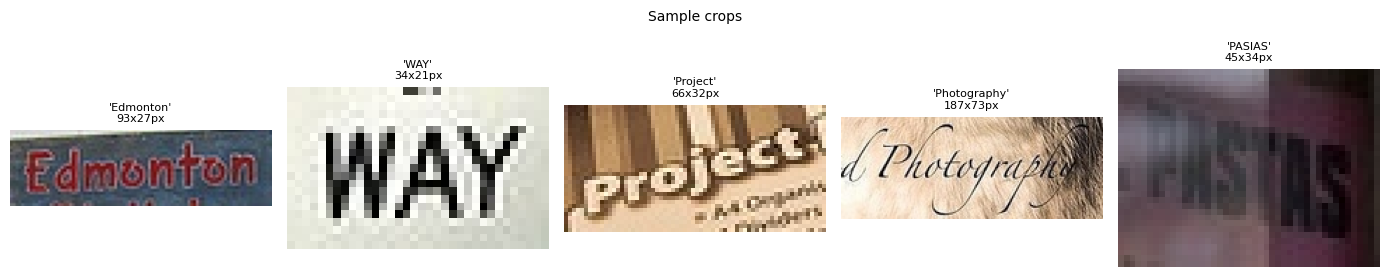

In [4]:
with open(SAMPLE_DIR / "recognition_sample.json") as f:
    recognition_sample = json.load(f)

# Verify all crop files exist
missing = [s for s in recognition_sample if not (CROPS_DIR / s["crop_file"]).exists()]
print(f"Crops loaded  : {len(recognition_sample)}")
print(f"Missing files : {len(missing)}  {'✓' if not missing else '← fix before continuing'}")

# Quick preview
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, s in zip(axes, recognition_sample[:5]):
    ax.imshow(Image.open(CROPS_DIR / s["crop_file"]))
    ax.set_title(f"'{s['gt_text']}'\n{s['crop_w']}x{s['crop_h']}px", fontsize=8)
    ax.axis("off")
plt.suptitle("Sample crops", fontsize=10)
plt.tight_layout(); plt.show()

## 4. CER / WER Utilities

In [5]:
def compute_cer(pred, gt):
    """Character Error Rate — edit distance at character level, clamped to 1.0."""
    pred, gt = pred.strip().lower(), gt.strip().lower()
    if not gt: return 0.0 if not pred else 1.0
    return min(1.0, editdistance.eval(pred, gt) / len(gt))

def compute_wer(pred, gt):
    """Word Error Rate — edit distance at word level, clamped to 1.0."""
    pw, gw = pred.strip().lower().split(), gt.strip().lower().split()
    if not gw: return 0.0 if not pw else 1.0
    return min(1.0, editdistance.eval(pw, gw) / len(gw))

# Sanity test
assert compute_cer("Hello", "Hello") == 0.0
assert compute_cer("Helo",  "Hello") == 0.2     # 1 error / 5 chars
assert compute_wer("cat sat", "the cat sat") > 0
print("CER/WER utilities verified ")

CER/WER utilities verified 


## 5. EasyOCR

In [6]:
import easyocr

print("Loading EasyOCR...")
easy_reader = easyocr.Reader(
    ['en'],
    gpu=(device=="cuda"),
    model_storage_directory=str(MODELS_DIR / "easyocr"),
    download_enabled=True,
    verbose=False
)
print("EasyOCR ready ")

Loading EasyOCR...
EasyOCR ready 


In [7]:
def run_easyocr(crop_img):
    """Returns (text, confidence, latency). Takes highest-confidence result from crop."""
    arr = np.array(crop_img)
    t0  = time.perf_counter()
    res = easy_reader.readtext(arr, detail=1, paragraph=False, batch_size=1)
    lat = time.perf_counter() - t0
    if not res: return "", 0.0, lat
    best = max(res, key=lambda r: r[2])
    return str(best[1]), float(best[2]), lat


print(f"Running EasyOCR on {len(recognition_sample)} crops...")
easy_results = []

for i, s in enumerate(recognition_sample):
    crop = Image.open(CROPS_DIR / s["crop_file"]).convert("RGB")
    pred, conf, lat = run_easyocr(crop)
    easy_results.append({
        "crop_id": s["crop_id"], "gt_text": s["gt_text"], "pred_text": pred,
        "confidence": conf, "cer": compute_cer(pred, s["gt_text"]),
        "wer": compute_wer(pred, s["gt_text"]), "latency": lat,
        "text_len": s["text_len"], "crop_file": s["crop_file"]
    })
    if (i+1)%100==0: print(f"  {i+1}/{len(recognition_sample)}")

df_easy = pd.DataFrame(easy_results)
print(f"\nEasyOCR:")
print(f"  Mean CER     : {df_easy['cer'].mean():.4f}")
print(f"  Mean WER     : {df_easy['wer'].mean():.4f}")
print(f"  Mean conf    : {df_easy['confidence'].mean():.4f}")
print(f"  P95 latency  : {df_easy['latency'].quantile(0.95):.4f}s")
print(f"  Above 0.75   : {(df_easy['confidence']>=CONF_THRESHOLD).mean()*100:.1f}% of crops")

Running EasyOCR on 500 crops...
  100/500
  200/500
  300/500
  400/500
  500/500

EasyOCR:
  Mean CER     : 0.5286
  Mean WER     : 0.7490
  Mean conf    : 0.3845
  P95 latency  : 0.0367s
  Above 0.75   : 24.0% of crops


## 6. TrOCR

In [8]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

CHECKPOINT = "microsoft/trocr-base-printed"
print(f"Loading TrOCR ({CHECKPOINT})...")

trocr_processor = TrOCRProcessor.from_pretrained(
    CHECKPOINT, cache_dir=str(MODELS_DIR / "trocr"))
trocr_model = VisionEncoderDecoderModel.from_pretrained(
    CHECKPOINT, cache_dir=str(MODELS_DIR / "trocr")).to(device)
trocr_model.eval()

params = sum(p.numel() for p in trocr_model.parameters()) / 1e6
print(f"TrOCR ready   ({params:.0f}M parameters)")

Loading TrOCR (microsoft/trocr-base-printed)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR ready   (334M parameters)


In [9]:
def run_trocr(crop_img):
    """Returns (text, confidence, latency). Confidence = mean per-token max softmax prob."""
    px = trocr_processor(images=crop_img, return_tensors="pt").pixel_values.to(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        out = trocr_model.generate(
            px, max_new_tokens=32,
            output_scores=True, return_dict_in_generate=True
        )
    lat = time.perf_counter() - t0
    pred = trocr_processor.batch_decode(out.sequences, skip_special_tokens=True)[0].strip()
    conf = float(np.mean([torch.softmax(s, dim=-1).max().item() for s in out.scores])) \
           if out.scores else 0.0
    return pred, conf, lat


print(f"Running TrOCR on {len(recognition_sample)} crops...")
trocr_results = []

for i, s in enumerate(recognition_sample):
    crop = Image.open(CROPS_DIR / s["crop_file"]).convert("RGB")
    pred, conf, lat = run_trocr(crop)
    trocr_results.append({
        "crop_id": s["crop_id"], "gt_text": s["gt_text"], "pred_text": pred,
        "confidence": conf, "cer": compute_cer(pred, s["gt_text"]),
        "wer": compute_wer(pred, s["gt_text"]), "latency": lat,
        "text_len": s["text_len"], "crop_file": s["crop_file"]
    })
    if (i+1)%100==0: print(f"  {i+1}/{len(recognition_sample)}")

df_trocr = pd.DataFrame(trocr_results)
print(f"\nTrOCR:")
print(f"  Mean CER     : {df_trocr['cer'].mean():.4f}")
print(f"  Mean WER     : {df_trocr['wer'].mean():.4f}")
print(f"  Mean conf    : {df_trocr['confidence'].mean():.4f}")
print(f"  P95 latency  : {df_trocr['latency'].quantile(0.95):.4f}s")
print(f"  Above 0.75   : {(df_trocr['confidence']>=CONF_THRESHOLD).mean()*100:.1f}% of crops")

Running TrOCR on 500 crops...
  100/500
  200/500
  300/500
  400/500
  500/500

TrOCR:
  Mean CER     : 0.3364
  Mean WER     : 0.5733
  Mean conf    : 0.7950
  P95 latency  : 0.1217s
  Above 0.75   : 61.8% of crops


## 7. Compare & Plot

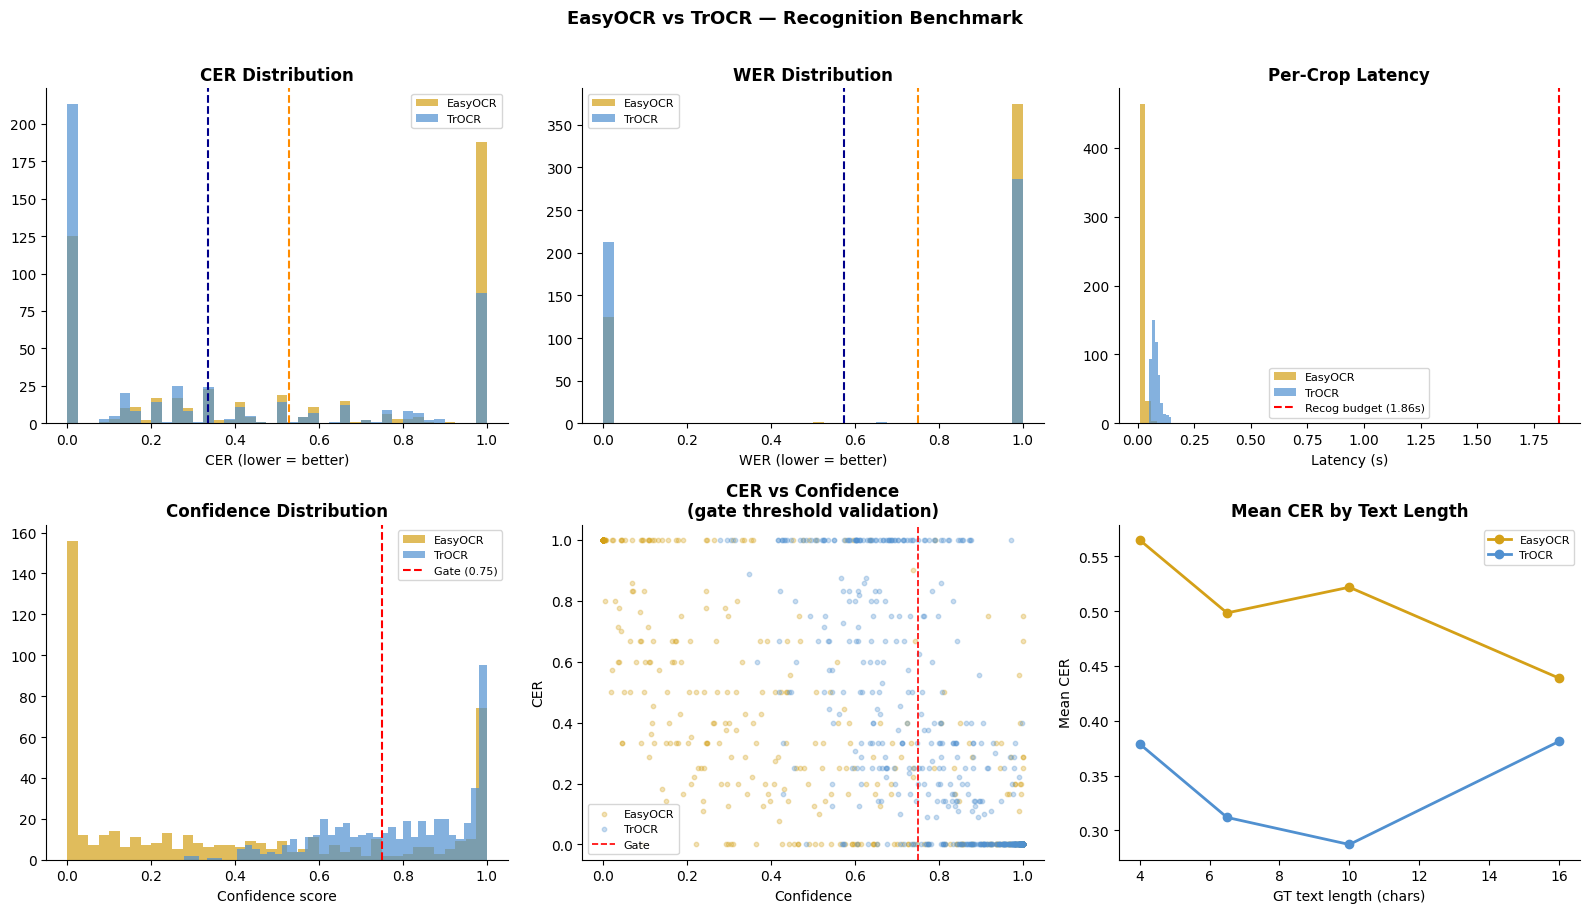

Figure saved 


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = ["#d4a017", "#5090d0"]

# CER
ax = axes[0,0]
ax.hist(df_easy['cer'],  bins=40, alpha=0.7, label="EasyOCR", color=colors[0])
ax.hist(df_trocr['cer'], bins=40, alpha=0.7, label="TrOCR",   color=colors[1])
ax.axvline(df_easy['cer'].mean(),  color="darkorange", linestyle="--", lw=1.5)
ax.axvline(df_trocr['cer'].mean(), color="darkblue",   linestyle="--", lw=1.5)
ax.set_title("CER Distribution", fontweight="bold")
ax.set_xlabel("CER (lower = better)")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# WER
ax = axes[0,1]
ax.hist(df_easy['wer'],  bins=40, alpha=0.7, label="EasyOCR", color=colors[0])
ax.hist(df_trocr['wer'], bins=40, alpha=0.7, label="TrOCR",   color=colors[1])
ax.axvline(df_easy['wer'].mean(),  color="darkorange", linestyle="--", lw=1.5)
ax.axvline(df_trocr['wer'].mean(), color="darkblue",   linestyle="--", lw=1.5)
ax.set_title("WER Distribution", fontweight="bold")
ax.set_xlabel("WER (lower = better)")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# Latency
ax = axes[0,2]
ax.hist(df_easy['latency'],  bins=40, alpha=0.7, label="EasyOCR", color=colors[0])
ax.hist(df_trocr['latency'], bins=40, alpha=0.7, label="TrOCR",   color=colors[1])
ax.axvline(RECOG_BUDGET, color="red", linestyle="--", lw=1.5, label=f"Recog budget ({RECOG_BUDGET:.2f}s)")
ax.set_title("Per-Crop Latency", fontweight="bold")
ax.set_xlabel("Latency (s)")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# Confidence distribution
ax = axes[1,0]
ax.hist(df_easy['confidence'],  bins=40, alpha=0.7, label="EasyOCR", color=colors[0])
ax.hist(df_trocr['confidence'], bins=40, alpha=0.7, label="TrOCR",   color=colors[1])
ax.axvline(CONF_THRESHOLD, color="red", linestyle="--", lw=1.5, label=f"Gate ({CONF_THRESHOLD})")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.set_xlabel("Confidence score")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# CER vs Confidence — gate validation
ax = axes[1,1]
ax.scatter(df_easy['confidence'],  df_easy['cer'],  alpha=0.3, s=10, color=colors[0], label="EasyOCR")
ax.scatter(df_trocr['confidence'], df_trocr['cer'], alpha=0.3, s=10, color=colors[1], label="TrOCR")
ax.axvline(CONF_THRESHOLD, color="red", linestyle="--", lw=1.2, label="Gate")
ax.set_title("CER vs Confidence\n(gate threshold validation)", fontweight="bold")
ax.set_xlabel("Confidence"); ax.set_ylabel("CER")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# CER by text length
ax = axes[1,2]
bins_l = [3, 5, 8, 12, 20, 50]
for df, name, color in [(df_easy,"EasyOCR",colors[0]),(df_trocr,"TrOCR",colors[1])]:
    means, mids = [], []
    for lo, hi in zip(bins_l[:-1], bins_l[1:]):
        mask = (df['text_len']>=lo)&(df['text_len']<hi)
        if mask.sum()>0:
            means.append(df.loc[mask,'cer'].mean())
            mids.append((lo+hi)/2)
    ax.plot(mids, means, marker="o", label=name, color=color, lw=2)
ax.set_title("Mean CER by Text Length", fontweight="bold")
ax.set_xlabel("GT text length (chars)"); ax.set_ylabel("Mean CER")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("EasyOCR vs TrOCR — Recognition Benchmark", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02b_recognition_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ")

## 8. Gate Validation

In [13]:
print(f"Confidence gate validation at threshold = {CONF_THRESHOLD} \n")
for df, name in [(df_easy,"EasyOCR"),(df_trocr,"TrOCR")]:
    above = df[df['confidence'] >= CONF_THRESHOLD]
    below = df[df['confidence'] <  CONF_THRESHOLD]
    print(f"  {name}")
    print(f"    Above gate => spoken  : n={len(above):>3}  CER={above['cer'].mean():.4f}  WER={above['wer'].mean():.4f}")
    print(f"    Below gate => silenced: n={len(below):>3}  CER={below['cer'].mean():.4f}  WER={below['wer'].mean():.4f}")
    if len(below)>0 and len(above)>0:
        imp = (below['cer'].mean()-above['cer'].mean())/below['cer'].mean()*100
        print(f" Gating cuts CER by {imp:.1f}% vs reading everything")
    print() 

Confidence gate validation at threshold = 0.75 

  EasyOCR
    Above gate => spoken  : n=120  CER=0.0857  WER=0.2458
    Below gate => silenced: n=380  CER=0.6684  WER=0.9079
 Gating cuts CER by 87.2% vs reading everything

  TrOCR
    Above gate => spoken  : n=309  CER=0.1465  WER=0.3517
    Below gate => silenced: n=191  CER=0.6436  WER=0.9319
 Gating cuts CER by 77.2% vs reading everything



## 9. Qualitative Sample

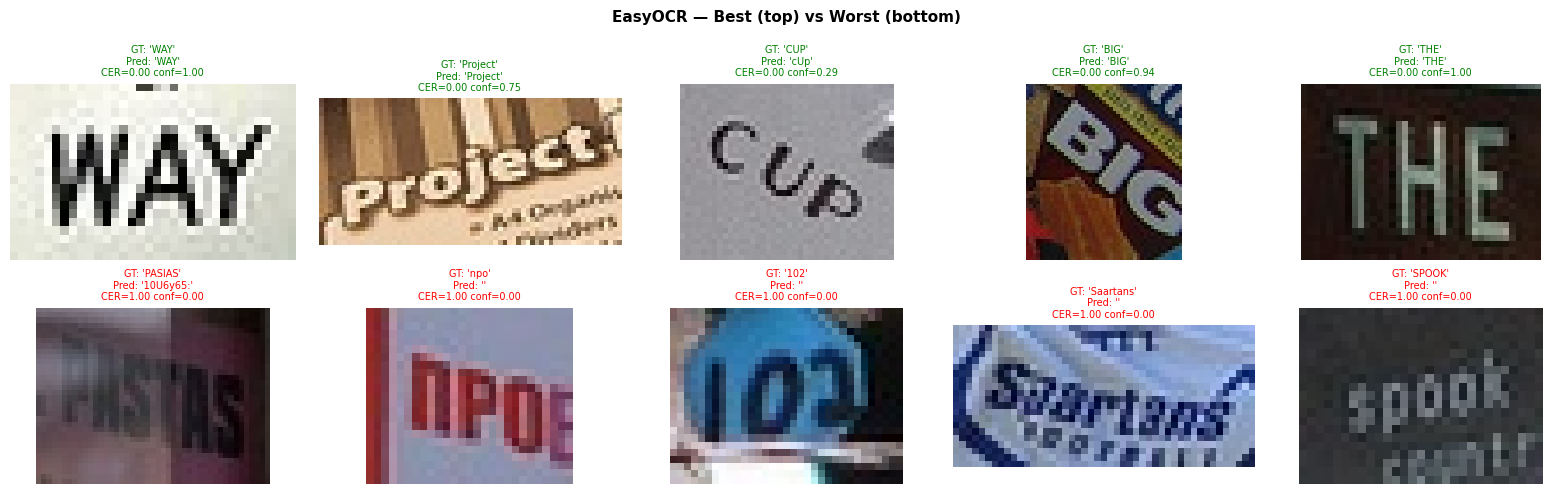

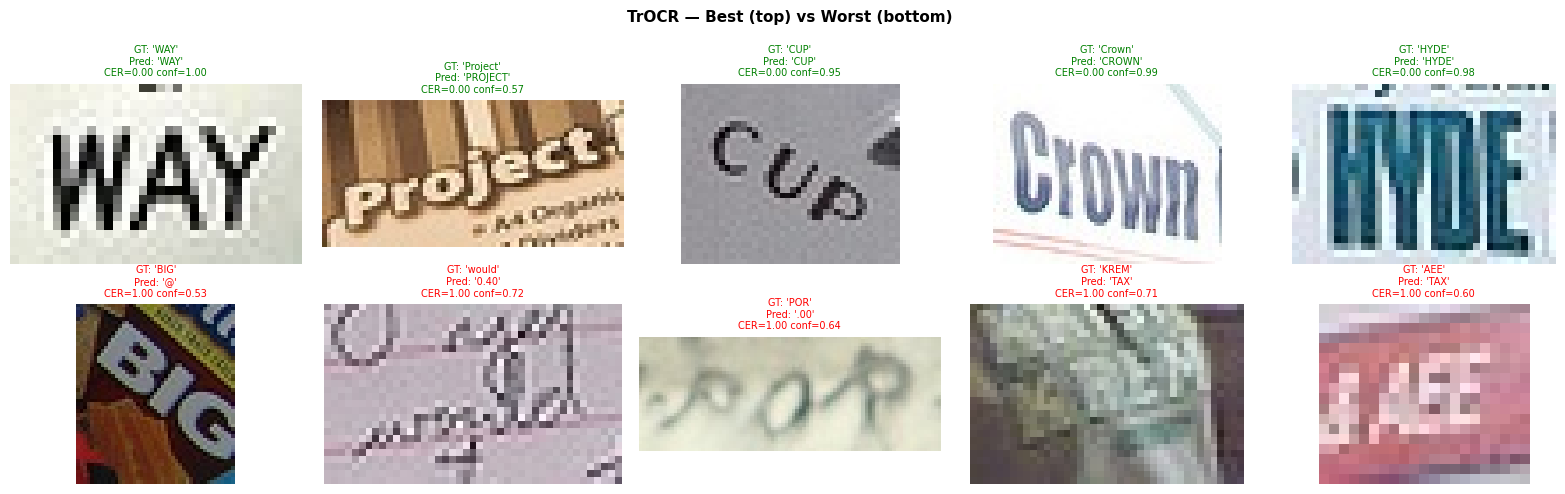

In [14]:
for df, name in [(df_easy, "EasyOCR"), (df_trocr, "TrOCR")]:
    best  = df.nsmallest(5, "cer")
    worst = df.nlargest(5, "cer")
    fig, axes = plt.subplots(2, 5, figsize=(16, 5))
    fig.suptitle(f"{name} — Best (top) vs Worst (bottom)", fontsize=11, fontweight="bold")
    for row_i, subset in enumerate([best, worst]):
        for col_i, (_, row) in enumerate(subset.iterrows()):
            ax = axes[row_i][col_i]
            crop_path = CROPS_DIR / row["crop_file"]
            if crop_path.exists(): ax.imshow(Image.open(crop_path))
            color = "green" if row["cer"] < 0.1 else "red"
            ax.set_title(
                f"GT: '{row['gt_text']}'\nPred: '{row['pred_text']}'\n"
                f"CER={row['cer']:.2f} conf={row['confidence']:.2f}",
                fontsize=7, color=color)
            ax.axis("off")
    plt.tight_layout(); plt.show()

## 10. Save & Decision

In [17]:
# Save per-crop CSVs
df_easy.to_csv(RESULTS_DIR  / "02b_easyocr_per_crop.csv",  index=False)
df_trocr.to_csv(RESULTS_DIR / "02b_trocr_per_crop.csv",    index=False)

# Summary
summary = pd.DataFrame({
    "Metric":  ["Mean CER","Mean WER","Mean Confidence","Mean Latency (s)",
                "P95 Latency (s)","% above 0.75 conf"],
    "EasyOCR": [df_easy['cer'].mean(),  df_easy['wer'].mean(),
                df_easy['confidence'].mean(), df_easy['latency'].mean(),
                df_easy['latency'].quantile(0.95),
                (df_easy['confidence']>=CONF_THRESHOLD).mean()*100],
    "TrOCR":   [df_trocr['cer'].mean(), df_trocr['wer'].mean(),
                df_trocr['confidence'].mean(), df_trocr['latency'].mean(),
                df_trocr['latency'].quantile(0.95),
                (df_trocr['confidence']>=CONF_THRESHOLD).mean()*100],
})
summary.to_csv(RESULTS_DIR / "02b_recognition_summary.csv", index=False)
print(summary.to_string(index=False))

# ── Decision ──

candidates = {}
for name, df in [("EasyOCR", df_easy), ("TrOCR", df_trocr)]:
    p95 = df['latency'].quantile(0.95)
    ok  = p95 < RECOG_BUDGET
    print(f"\n  {name}")
    print(f"    Mean CER     : {df['cer'].mean():.4f}")
    print(f"    Mean WER     : {df['wer'].mean():.4f}")
    print(f"    P95 latency  : {p95:.3f}s  {'✓ within budget' if ok else '✗ EXCEEDS BUDGET'}")
    if ok: candidates[name] = {"cer": df['cer'].mean(), "p95_lat": p95}

rec_winner = min(candidates, key=lambda n: candidates[n]["cer"]) if candidates else None

with open(RESULTS_DIR / "02a_decision.json") as f:
    det = json.load(f)

final = {"detection_winner":  det.get("detection_winner"),
         "recognition_winner": rec_winner}

with open(RESULTS_DIR / "02b_decision.json", "w") as f:
    json.dump(final, f, indent=2)

print(f"  Detection   : {final['detection_winner']}")
print(f"  Recognition : {final['recognition_winner']}")

           Metric   EasyOCR     TrOCR
         Mean CER  0.528578  0.336357
         Mean WER  0.749000  0.573333
  Mean Confidence  0.384461  0.794982
 Mean Latency (s)  0.020181  0.081801
  P95 Latency (s)  0.036730  0.121653
% above 0.75 conf 24.000000 61.800000

  EasyOCR
    Mean CER     : 0.5286
    Mean WER     : 0.7490
    P95 latency  : 0.037s  ✓ within budget

  TrOCR
    Mean CER     : 0.3364
    Mean WER     : 0.5733
    P95 latency  : 0.122s  ✓ within budget
  Detection   : db_resnet50
  Recognition : TrOCR


## **RECOGNITION DECISION**
================================================

  **EasyOCR**

    Mean CER     : 0.5286
    Mean WER     : 0.7490
    P95 latency  : 0.035s  ✓ within budget

  **TrOCR**

    Mean CER     : 0.3364
    Mean WER     : 0.5733
    P95 latency  : 0.140s  ✓ within budget

  **FULL STACK CONFIRMED**

 **Detection**  : db_resnet50
  **Recognition** : TrOCR
 
  **Next step** : 
  
  Baseline MVP